<a href="https://colab.research.google.com/github/Houinni/fnirs-pipeline/blob/main/run_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HRfunc fNIRS Analysis Pipeline

Uses MNE's built-in `fnirs_motor` dataset (auto-downloaded) to demonstrate the full HRfunc workflow:

**load data → estimate HRFs → generate distribution → estimate neural activity**

- **Dataset:** Finger-tapping task (Control / Tapping-Left / Tapping-Right)
- **Format:** NIRX
- **Source:** https://mne.tools/stable/auto_tutorials/preprocessing/70_fnirs_processing.html

## Configuration

### Set up Conda environment (using Mambaforge)

First, we'll install `mambaforge` which includes `conda` and `mamba`. Then, we'll use `mamba` to install the `mne` and `hrfunc` packages, which are causing a `ModuleNotFoundError`.

In [ ]:
# Install mne and hrfunc using pip
!pip install -q mne hrfunc

# Restarting the kernel is often recommended after extensive environment changes,
# but for simple package installs, it might not be strictly necessary.
# However, to be safe, a kernel restart might resolve any lingering import issues.
print("MNE and hrfunc installed. Please restart the runtime (Runtime -> Restart runtime) if you encounter further import errors.")

MNE and hrfunc installed. Please restart the runtime (Runtime -> Restart runtime) if you encounter further import errors.


In [ ]:
import os
import numpy as np
import mne
import hrfunc as hrf
from itertools import compress

import matplotlib.pyplot as plt

HRF_DURATION = 30.0   # seconds
HRF_LAMBDA   = 1.0    # Tikhonov regularization strength
HRF_OUTPUT   = "study_HRFs.json"
OUTPUT_DIR   = "output"

## Step 1 — Load MNE Sample fNIRS Data

In [ ]:
fnirs_data_folder = mne.datasets.fnirs_motor.data_path()
fnirs_cw_amplitude_dir = fnirs_data_folder / "Participant-1"

raw_intensity = mne.io.read_raw_nirx(fnirs_cw_amplitude_dir, preload=True)
raw_intensity.load_data()


Using default location ~/mne_data for fnirs_motor...
Creating /root/mne_data


  0%|                                              | 0.00/17.9M [00:00<?, ?B/s]

Untarring contents of '/root/mne_data/MNE-fNIRS-motor-data.tgz' to '/root/mne_data'


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 05s (17.1 MB)
Loading /root/mne_data/MNE-fNIRS-motor-data/Participant-1
Reading 0 ... 23238  =      0.000 ...  2974.464 secs...


<RawNIRX | Participant-1, 56 x 23239 (2974.6 s), ~10.0 MiB, data loaded>

## Step 1a - Viewing location of sensors over brain surface

In [ ]:
subjects_dir = mne.datasets.sample.data_path() / "subjects"

brain = mne.viz.Brain(
    "fsaverage", subjects_dir=subjects_dir, background="w", cortex="0.5"
)
brain.add_sensors(
    raw_intensity.info,
    trans="fsaverage",
    fnirs=["channels", "pairs", "sources", "detectors"],
)
brain.show_view(azimuth=20, elevation=60, distance=400)

Using default location ~/mne_data for sample...


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of '/root/mne_data/MNE-sample-data-processed.tar.gz' to '/root/mne_data'


Download complete in 01m37s (1576.2 MB)


RuntimeError: Could not load any valid 3D backend
pyvistaqt: No module named 'qtpy'
notebook: No module named 'pyvista'

 install pyvistaqt, using pip or conda:
'pip install pyvistaqt'
'conda install -c conda-forge pyvistaqt'

 or install ipywidgets, if using a notebook backend
'pip install ipywidgets'
'conda install -c conda-forge ipywidgets'

## Step 1b — Prepare Annotations → Event Impulse Series

In [ ]:
# Clean up annotations (following the MNE tutorial)
raw_intensity.annotations.set_durations(5)
descriptions = set(raw_intensity.annotations.description)
mapping = {"1.0": "Control", "2.0": "Tapping/Left", "3.0": "Tapping/Right"}
mapping = {k: v for k, v in mapping.items() if k in descriptions}
if mapping:
    raw_intensity.annotations.rename(mapping)

unwanted = np.nonzero(raw_intensity.annotations.description == "15.0")[0]
if len(unwanted) > 0:
    raw_intensity.annotations.delete(unwanted)

# Remove short channels (distance < 1 cm)
picks = mne.pick_types(raw_intensity.info, meg=False, fnirs=True)
dists = mne.preprocessing.nirs.source_detector_distances(raw_intensity.info, picks=picks)
raw_intensity.pick(picks[dists > 0.01])
print(f"Channels after short-channel removal: {len(raw_intensity.ch_names)}")

# Build binary event impulse series (length = number of samples)
n_samples = len(raw_intensity.times)
events_array, event_dict = mne.events_from_annotations(raw_intensity)
event_impulse = [0] * n_samples
for event in events_array:
    sample_idx = event[0]
    if 0 <= sample_idx < n_samples:
        event_impulse[sample_idx] = 1

print(f"Impulse series: {n_samples} samples, {sum(event_impulse)} events")
print(f"Event types: {event_dict}")

Channels after short-channel removal: 40
Used Annotations descriptions: [np.str_('Control'), np.str_('Tapping/Left'), np.str_('Tapping/Right')]
Impulse series: 23239 samples, 90 events
Event types: {np.str_('Control'): 1, np.str_('Tapping/Left'): 2, np.str_('Tapping/Right'): 3}


## Step 2 — Estimate Subject-Level HRFs

In [ ]:
raw_scans = [raw_intensity]

montage = hrf.montage(raw_scans[0])
for i, scan in enumerate(raw_scans, 1):
    print(f"Scan {i}/{len(raw_scans)} ...")
    montage.estimate_hrf(scan, event_impulse, duration=HRF_DURATION, lmbda=HRF_LAMBDA)

print("Subject-level HRF estimation complete.")
print(f"HbO channels: {montage.hbo_channels}")
print(f"HbR channels: {montage.hbr_channels}")

Setting root... s1_d1_hbo
Table below minimum fill, decreasing capacity to 1
Table exceeding maximum fill, increasing capacity to 2
Table exceeding maximum fill, increasing capacity to 4
Table exceeding maximum fill, increasing capacity to 8
Table exceeding maximum fill, increasing capacity to 16
Table exceeding maximum fill, increasing capacity to 32
Tree initialized with HRFs from /usr/local/lib/python3.12/dist-packages/hrfunc/hrfs/hbo_hrfs.json
Setting root... s1_d1_hbr
Table below minimum fill, decreasing capacity to 1
Table exceeding maximum fill, increasing capacity to 2
Table exceeding maximum fill, increasing capacity to 4
Table exceeding maximum fill, increasing capacity to 8
Table exceeding maximum fill, increasing capacity to 16
Table exceeding maximum fill, increasing capacity to 32
Tree initialized with HRFs from /usr/local/lib/python3.12/dist-packages/hrfunc/hrfs/hbr_hrfs.json
Configureding HRfunc montage...
Searching for s1_d1_hbr
No matching HRF found, inserting new HRF

/usr/local/lib/python3.12/dist-packages/hrfunc/hrfunc.py:789: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  raw_od.interpolate_bads(reset_bads=False)


Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

## Step 3 — Generate Group-Level HRF Distribution

In [ ]:
montage.generate_distribution()
montage.save(HRF_OUTPUT)
print(f"Saved group HRFs to '{HRF_OUTPUT}'")

Saved group HRFs to 'study_HRFs.json'


## Step 3a — Plot Estimated HRFs per Channel

Comparable to the MNE tutorial's epoch-averaged waveforms. Instead of averaging
epochs, hrfunc estimates the HRF via Toeplitz deconvolution. We plot the mean ± 1 SD
for each HbO and HbR channel.

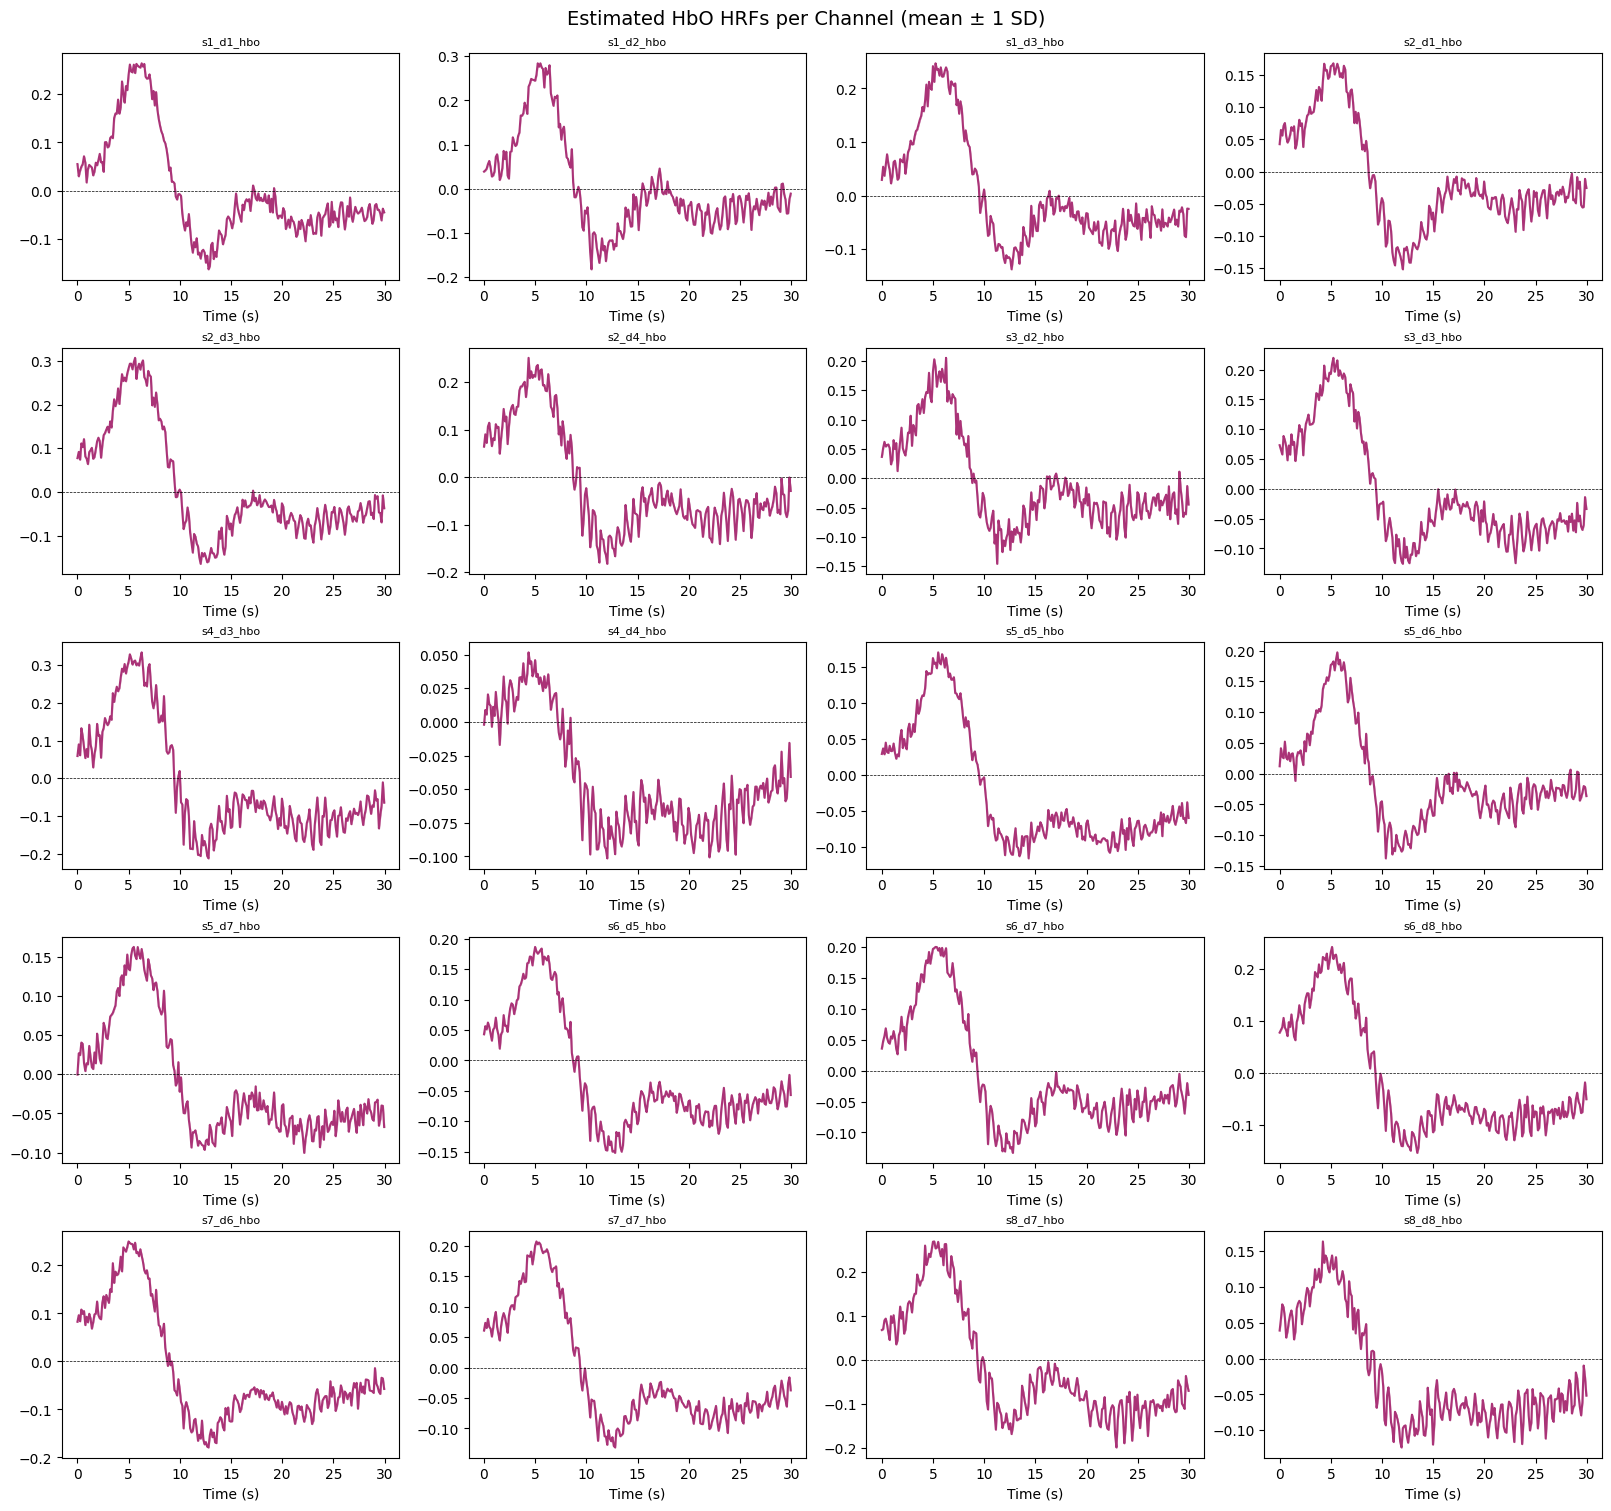

In [ ]:
# Plot all HbO channel HRFs in a grid
n_hbo = len(montage.hbo_channels)
ncols = 4
nrows = int(np.ceil(n_hbo / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows), layout="constrained")
axes = axes.flatten()

for idx, ch_name in enumerate(montage.hbo_channels):
    optode = montage.channels[ch_name]
    if len(optode.trace) == 0:
        continue
    time = np.arange(len(optode.trace)) / optode.sfreq
    axes[idx].plot(time, optode.trace, color="#AA3377", label="Mean HRF")
    if optode.trace_std is not None:
        axes[idx].fill_between(
            time,
            optode.trace - optode.trace_std,
            optode.trace + optode.trace_std,
            color="#AA3377", alpha=0.3
        )
    axes[idx].set_title(ch_name, fontsize=8)
    axes[idx].axhline(0, color="k", linewidth=0.5, linestyle="--")
    axes[idx].set_xlabel("Time (s)")

for idx in range(n_hbo, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Estimated HbO HRFs per Channel (mean ± 1 SD)", fontsize=14)
plt.show()

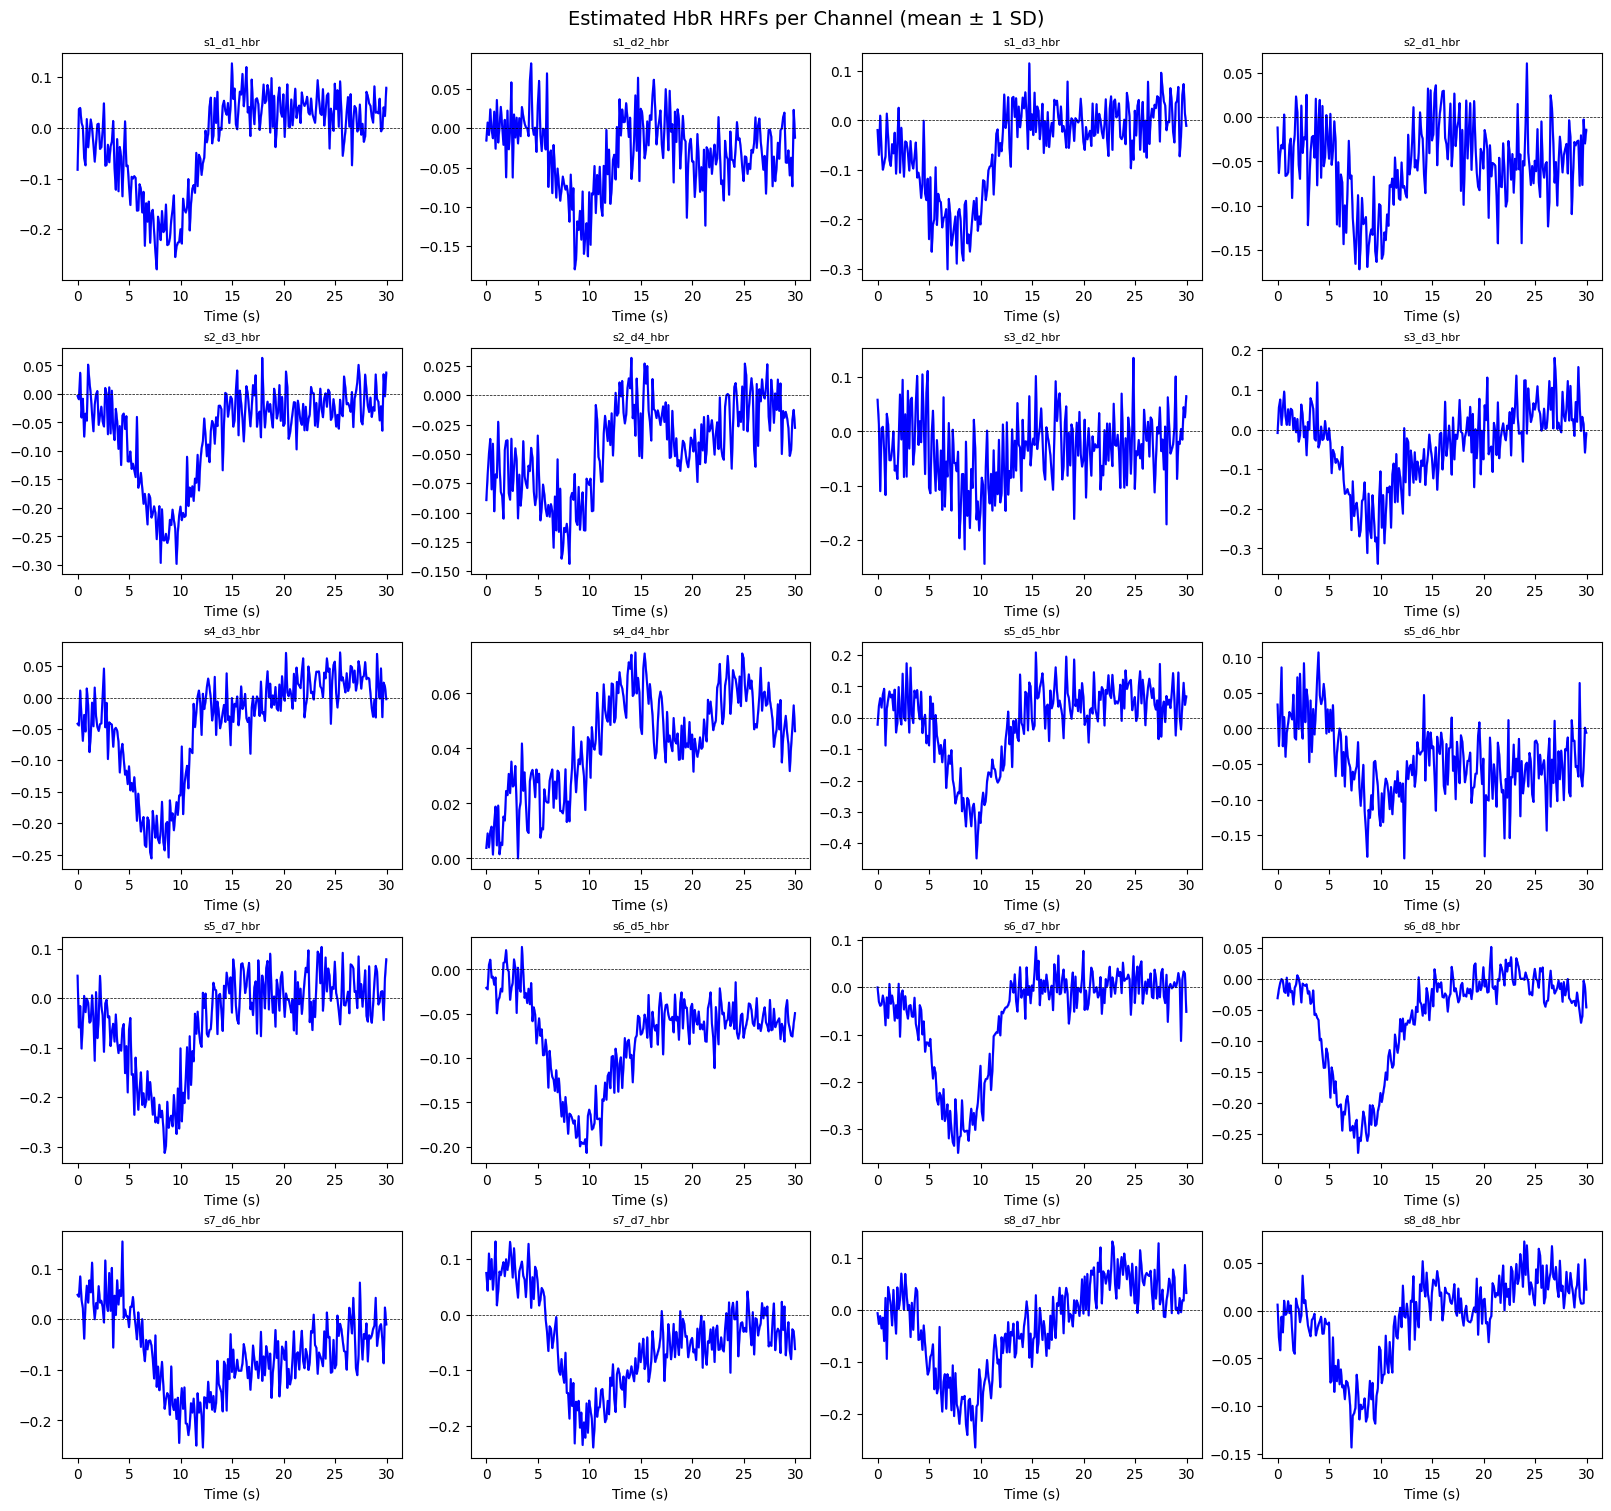

In [ ]:
# Plot all HbR channel HRFs in a grid
n_hbr = len(montage.hbr_channels)
nrows = int(np.ceil(n_hbr / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows), layout="constrained")
axes = axes.flatten()

for idx, ch_name in enumerate(montage.hbr_channels):
    optode = montage.channels[ch_name]
    if len(optode.trace) == 0:
        continue
    time = np.arange(len(optode.trace)) / optode.sfreq
    axes[idx].plot(time, optode.trace, color="b", label="Mean HRF")
    if optode.trace_std is not None:
        axes[idx].fill_between(
            time,
            optode.trace - optode.trace_std,
            optode.trace + optode.trace_std,
            color="b", alpha=0.3
        )
    axes[idx].set_title(ch_name, fontsize=8)
    axes[idx].axhline(0, color="k", linewidth=0.5, linestyle="--")
    axes[idx].set_xlabel("Time (s)")

for idx in range(n_hbr, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Estimated HbR HRFs per Channel (mean ± 1 SD)", fontsize=14)
plt.show()

## Step 3b — Global HbO vs HbR Response

Comparable to the MNE tutorial's `plot_compare_evokeds` showing the standard
fNIRS response (HbO peak ~6s, HbR dip slightly delayed).

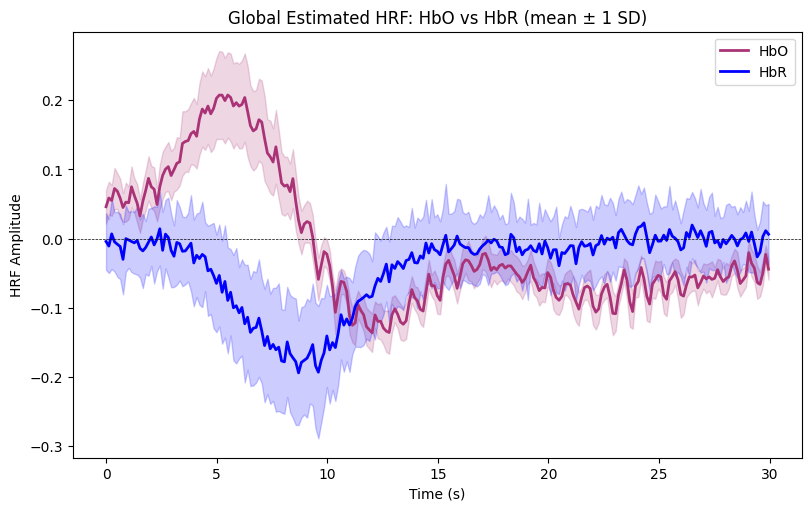

In [ ]:
# Plot global HbO vs HbR HRFs
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

global_hbo = montage.channels["global_hbo"]
global_hbr = montage.channels["global_hbr"]

time_hbo = np.arange(len(global_hbo.trace)) / global_hbo.sfreq
time_hbr = np.arange(len(global_hbr.trace)) / global_hbr.sfreq

ax.plot(time_hbo, global_hbo.trace, color="#AA3377", linewidth=2, label="HbO")
ax.fill_between(
    time_hbo,
    global_hbo.trace - global_hbo.trace_std,
    global_hbo.trace + global_hbo.trace_std,
    color="#AA3377", alpha=0.2
)

ax.plot(time_hbr, global_hbr.trace, color="b", linewidth=2, label="HbR")
ax.fill_between(
    time_hbr,
    global_hbr.trace - global_hbr.trace_std,
    global_hbr.trace + global_hbr.trace_std,
    color="b", alpha=0.2
)

ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
ax.set_xlabel("Time (s)")
ax.set_ylabel("HRF Amplitude")
ax.set_title("Global Estimated HRF: HbO vs HbR (mean ± 1 SD)")
ax.legend()
plt.show()

## Step 3c — HRF Consistency Across Channels

Comparable to the MNE tutorial's channel consistency image plots. Here we overlay
all per-channel HRFs to visualize how consistent the hemodynamic response is
across the montage.

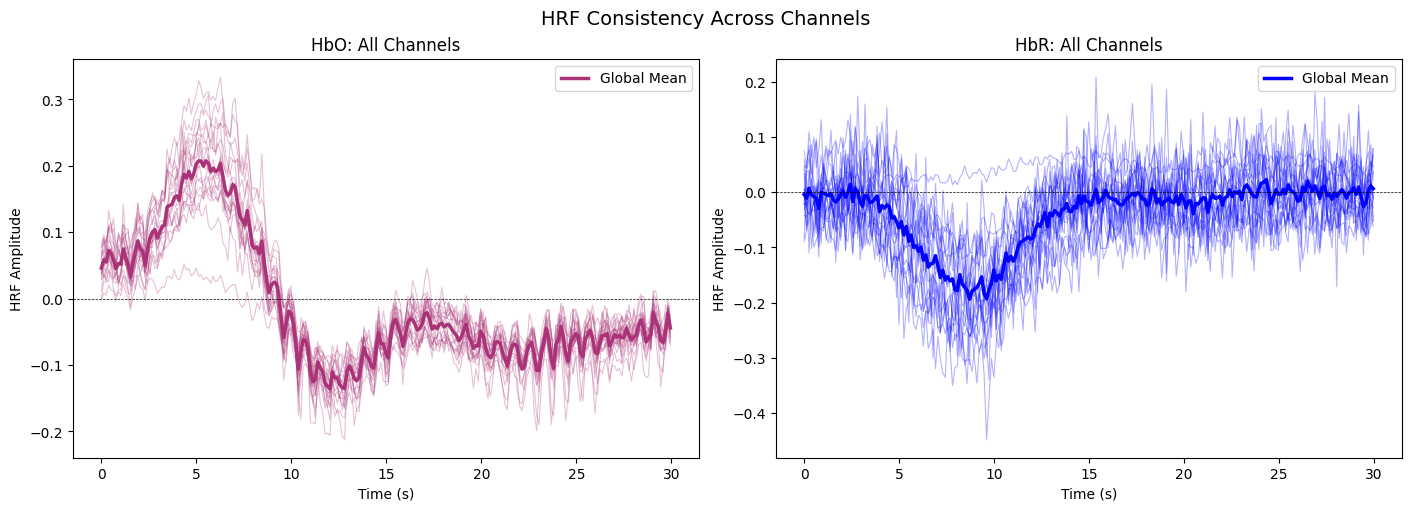

In [ ]:
# Overlay all channel HRFs + global mean to show consistency
fig, axes = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")

# HbO overlay
for ch_name in montage.hbo_channels:
    optode = montage.channels[ch_name]
    if len(optode.trace) == 0:
        continue
    time = np.arange(len(optode.trace)) / optode.sfreq
    axes[0].plot(time, optode.trace, color="#AA3377", alpha=0.3, linewidth=0.8)

time_global = np.arange(len(global_hbo.trace)) / global_hbo.sfreq
axes[0].plot(time_global, global_hbo.trace, color="#AA3377", linewidth=2.5, label="Global Mean")
axes[0].axhline(0, color="k", linewidth=0.5, linestyle="--")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("HRF Amplitude")
axes[0].set_title("HbO: All Channels")
axes[0].legend()

# HbR overlay
for ch_name in montage.hbr_channels:
    optode = montage.channels[ch_name]
    if len(optode.trace) == 0:
        continue
    time = np.arange(len(optode.trace)) / optode.sfreq
    axes[1].plot(time, optode.trace, color="b", alpha=0.3, linewidth=0.8)

time_global = np.arange(len(global_hbr.trace)) / global_hbr.sfreq
axes[1].plot(time_global, global_hbr.trace, color="b", linewidth=2.5, label="Global Mean")
axes[1].axhline(0, color="k", linewidth=0.5, linestyle="--")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("HRF Amplitude")
axes[1].set_title("HbR: All Channels")
axes[1].legend()

fig.suptitle("HRF Consistency Across Channels", fontsize=14)
plt.show()

## Step 4 — Estimate Neural Activity

In [ ]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Preprocess at full sample rate (OD → SCI → TDDR → Beer-Lambert → baseline)
# preprocess_fnirs returns a NEW object with hbo/hbr channel types
raw_deconv = hrf.preprocess_fnirs(raw_intensity.copy(), deconvolution=True)
print(f"Preprocessed ch_types: {sorted(set(raw_deconv.get_channel_types()))}")

# Downsample to 2 Hz to speed up deconvolution
raw_deconv.resample(2.0)
print(f"Downsampled: {raw_deconv.info['sfreq']} Hz, {len(raw_deconv.times)} samples")

raw_scans_deconv = [raw_deconv]

for i, scan in enumerate(raw_scans_deconv, 1):
    print(f"Scan {i}/{len(raw_scans_deconv)} ...")
    montage.estimate_activity(scan, preprocess=False)
    out_path = os.path.join(OUTPUT_DIR, f"sub-{i}_deconvolved.fif")
    scan.save(out_path, overwrite=True)
    print(f"Saved -> {out_path}")

print("Neural activity estimation complete.")

Setting channel interpolation method to {'fnirs': 'nearest'}.


/usr/local/lib/python3.12/dist-packages/hrfunc/hrfunc.py:789: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  raw_od.interpolate_bads(reset_bads=False)


Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

## Step 5 — Epoch Deconvolved Neural Activity

After hrfunc deconvolution, we epoch the estimated neural activity using MNE —
the same way the tutorial epochs haemoglobin data. This lets us produce directly
comparable plots (image plots, evoked responses, topomaps).

In [ ]:
# Extract events and epoch the deconvolved data
events, event_dict = mne.events_from_annotations(raw_deconv)
fig = mne.viz.plot_events(events, event_id=event_dict, sfreq=raw_deconv.info["sfreq"])


tmin, tmax = -5, 15

epochs = mne.Epochs(
    raw_deconv,
    events,
    event_id=event_dict,
    tmin=tmin,
    tmax=tmax,
    reject_by_annotation=True,
    proj=True,
    baseline=(None, 0),
    preload=True,
    detrend=None,
    verbose=True,
)
epochs.plot_drop_log()

## Step 5a — View Consistency of Neural Activity Across Trials

Comparable to the MNE tutorial's `epochs["Tapping"].plot_image()`. Here we
visualize the deconvolved neural activity instead of raw haemoglobin.

In [ ]:
# Tapping trials — deconvolved neural activity
epochs["Tapping"].plot_image(
    combine="mean",
    vmin=-100,
    vmax=100,
    ts_args=dict(ylim=dict(hbo=[-15, 15], hbr=[-15, 15])),
)

NameError: name 'epochs' is not defined

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"
combining channels using "mean"


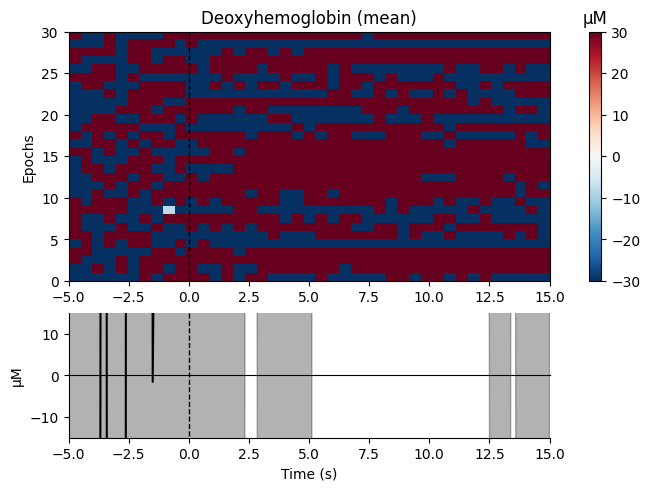

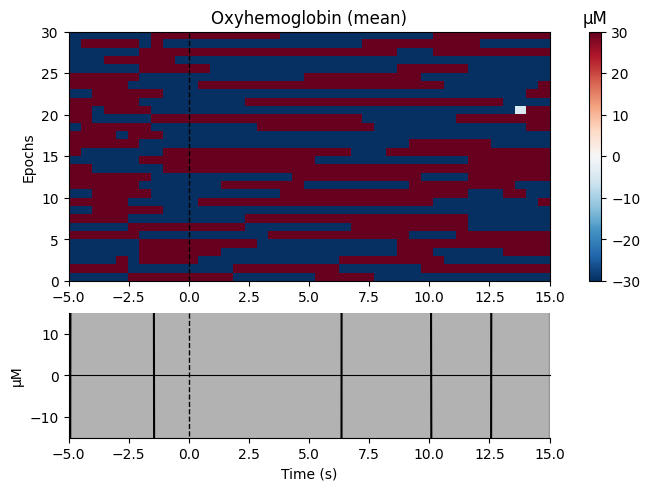

[<Figure size 640x480 with 3 Axes>, <Figure size 640x480 with 3 Axes>]

In [ ]:
# Control trials — deconvolved neural activity
epochs["Control"].plot_image(
    combine="mean",
    vmin=-30,
    vmax=30,
    ts_args=dict(ylim=dict(hbo=[-15, 15], hbr=[-15, 15])),
)

## Step 5b — Consistency Across Channels (Deconvolved)

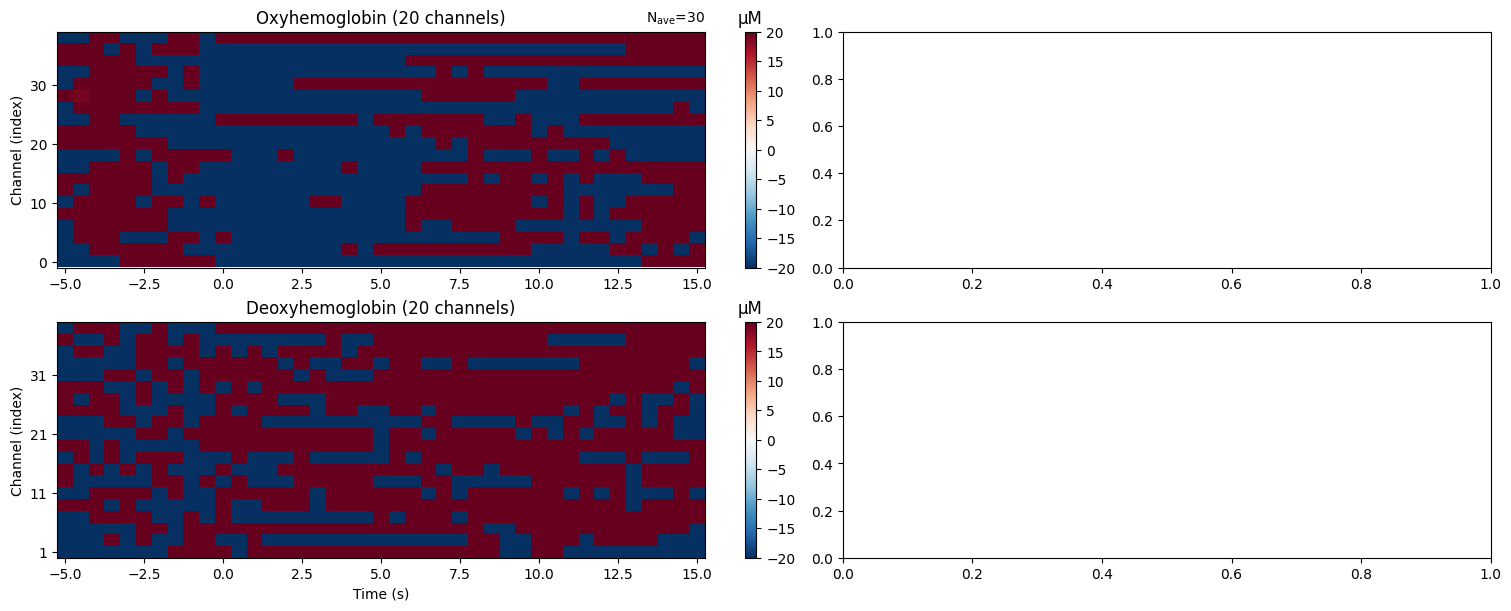

/usr/local/lib/python3.12/dist-packages/mne/viz/evoked.py:951: UserWarning: Adding colorbar to a different Figure <Figure size 1500x600 with 7 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(im, ax=ax)
/usr/local/lib/python3.12/dist-packages/mne/viz/evoked.py:951: UserWarning: Adding colorbar to a different Figure <Figure size 1500x600 with 8 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(im, ax=ax)


<Figure size 640x480 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 6), layout="constrained")
clims = dict(hbo=[-20, 20], hbr=[-20, 20])
epochs["Control"].average().plot_image(axes=axes[:, 0], clim=clims)
epochs["Tapping"].average().plot_image(axes=axes[:, 1], clim=clims)
for column, condition in enumerate(["Control", "Tapping"]):
    for ax in axes[:, column]:
        ax.set_title(f"{condition}: {ax.get_title()}")

## Step 5c — Standard Evoked Response (Deconvolved)

Comparable to the MNE tutorial's `plot_compare_evokeds` — HbO and HbR for
Tapping vs Control, now showing estimated neural activity rather than raw
haemodynamic response.

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


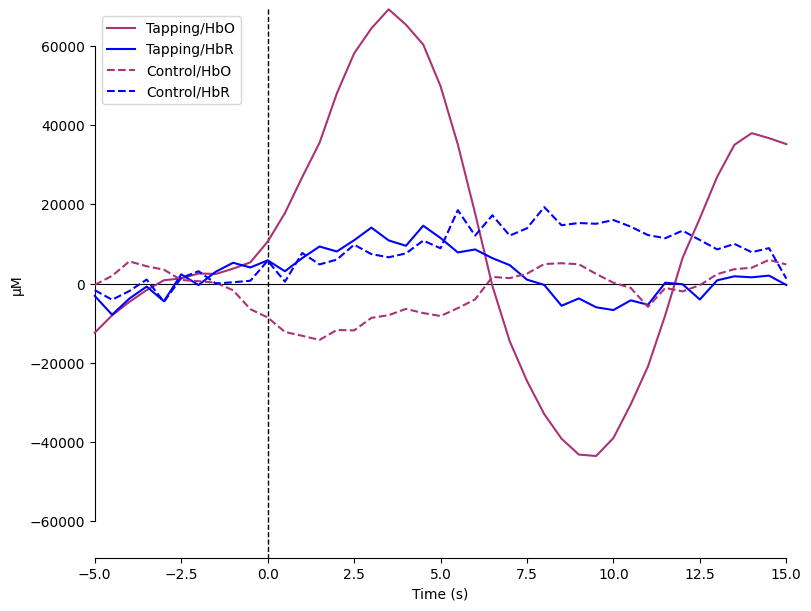

[<Figure size 800x600 with 1 Axes>]

In [ ]:
evoked_dict = {
    "Tapping/HbO": epochs["Tapping"].average(picks="hbo"),
    "Tapping/HbR": epochs["Tapping"].average(picks="hbr"),
    "Control/HbO": epochs["Control"].average(picks="hbo"),
    "Control/HbR": epochs["Control"].average(picks="hbr"),
}

# Rename channels until the encoding of frequency in ch_name is fixed
for condition in evoked_dict:
    evoked_dict[condition].rename_channels(lambda x: x[:-4])

color_dict = dict(HbO="#AA3377", HbR="b")
styles_dict = dict(Control=dict(linestyle="dashed"))

mne.viz.plot_compare_evokeds(
    evoked_dict, combine="mean", ci=0.95, colors=color_dict, styles=styles_dict
)

## Step 5d — Topographic Representation of Neural Activity

Comparable to the MNE tutorial's `plot_joint` and topomap comparisons.

No projector specified for this dataset. Please consider the method self.add_proj.


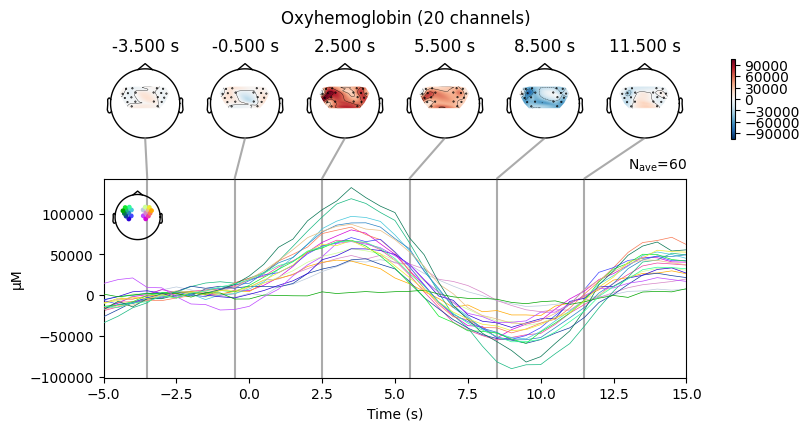

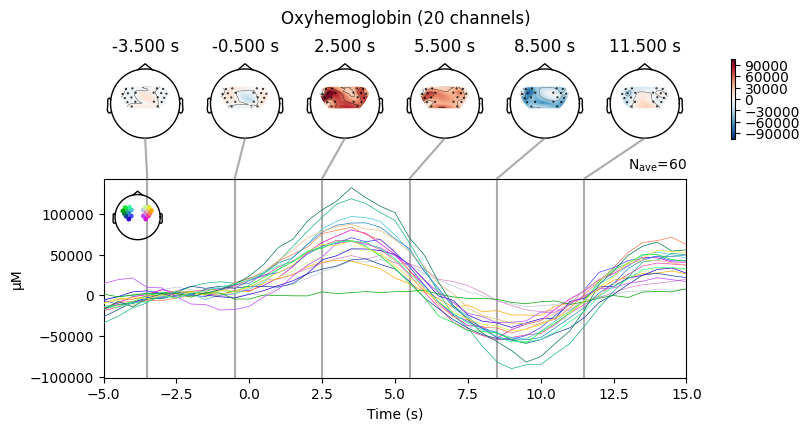

In [ ]:
# Topographic activity over time — Tapping HbO
times = np.arange(-3.5, 13.2, 3.0)
topomap_args = dict(extrapolate="local")
epochs["Tapping"].average(picks="hbo").plot_joint(
    times=times, topomap_args=topomap_args
)

## Step 5e — Left vs Right Tapping Comparison

Comparable to the MNE tutorial's left/right topomap comparison.

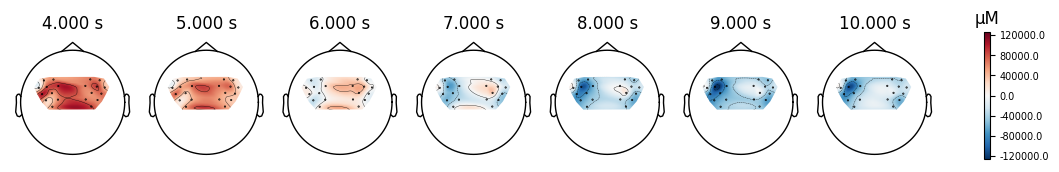

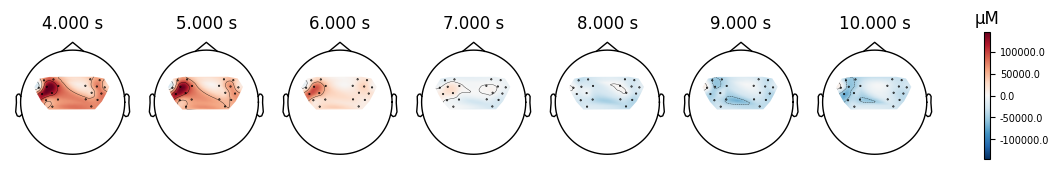

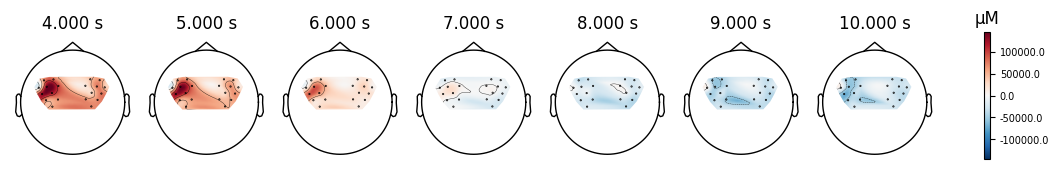

In [ ]:
# Left vs Right tapping — HbO topomaps
times = np.arange(4.0, 11.0, 1.0)
epochs["Tapping/Left"].average(picks="hbo").plot_topomap(times=times, **topomap_args)
epochs["Tapping/Right"].average(picks="hbo").plot_topomap(times=times, **topomap_args)

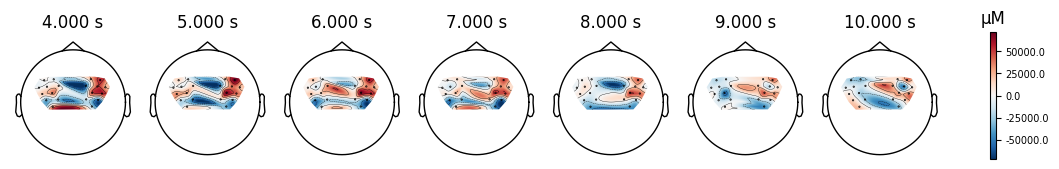

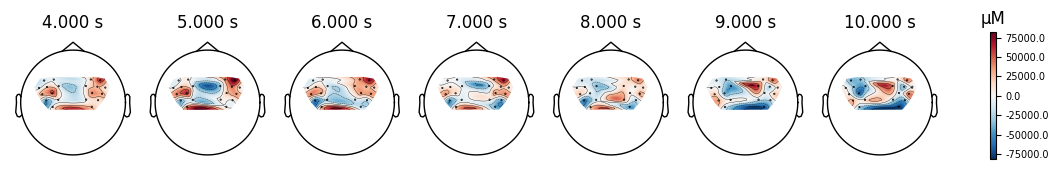

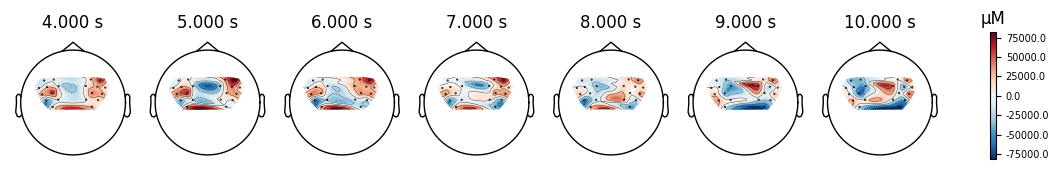

In [ ]:
# Left vs Right tapping — HbR topomaps
epochs["Tapping/Left"].average(picks="hbr").plot_topomap(times=times, **topomap_args)
epochs["Tapping/Right"].average(picks="hbr").plot_topomap(times=times, **topomap_args)

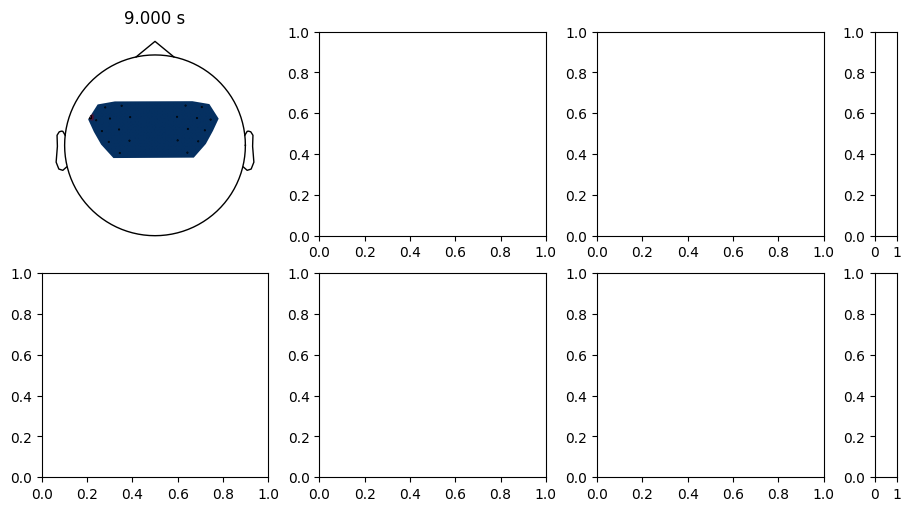

In [ ]:
# Side-by-side Left vs Right vs Difference at t=9s
fig, axes = plt.subplots(
    nrows=2, ncols=4, figsize=(9, 5),
    gridspec_kw=dict(width_ratios=[1, 1, 1, 0.1]),
    layout="constrained",
)
vlim = (-8, 8)
ts = 9.0

evoked_left = epochs["Tapping/Left"].average()
evoked_right = epochs["Tapping/Right"].average()

evoked_left.plot_topomap(
    ch_type="hbo", times=ts, axes=axes[0, 0], vlim=vlim, colorbar=False, **topomap_args
)
evoked_left.plot_topomap(
    ch_type="hbr", times=ts, axes=axes[1, 0], vlim=vlim, colorbar=False, **topomap_args
)
evoked_right.plot_topomap(
    ch_type="hbo", times=ts, axes=axes[0, 1], vlim=vlim, colorbar=False, **topomap_args
)
evoked_right.plot_topomap(
    ch_type="hbr", times=ts, axes=axes[1, 1], vlim=vlim, colorbar=False, **topomap_args
)

evoked_diff = mne.combine_evoked([evoked_left, evoked_right], weights=[1, -1])

evoked_diff.plot_topomap(
    ch_type="hbo", times=ts, axes=axes[0, 2:], vlim=vlim, colorbar=True, **topomap_args
)
evoked_diff.plot_topomap(
    ch_type="hbr", times=ts, axes=axes[1, 2:], vlim=vlim, colorbar=True, **topomap_args
)

for column, condition in enumerate(["Tapping Left", "Tapping Right", "Left-Right"]):
    for row, chroma in enumerate(["HbO", "HbR"]):
        axes[row, column].set_title(f"{chroma}: {condition}")